In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o')

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

search_tool.invoke("Obama's first name?")

'1 day ago -Barack Hussein Obama II(born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American president. Obama previously served as a U.S. senator representing Illinois from ... 5 days ago -Barack Hussein Obama II(/bəˈrɑːk huːˈseɪn oʊˈbɑːmə/ ; born August 4, 1961) is an American politician and attorney. He was the 44th president of the United States from 2009 to 2017. November 25, 2025 -Obama is a surname. It most commonly refers toBarack Obama(born 1961), the 44th president of the United States. Obama is a common Fang masculine name in western Central Africa. 1 week ago -Barack Hussein Obama(/ˈbærək huːˈseɪn oʊˈbɑːmə/; born Baraka Hussein Obama, 18 June 1934 – 24 November 1982) was a Kenyan senior governmental economist and the father of Barack Obama, a former president of the United States. February 4, 2026 -The selection was slow because Malia is allergic

In [4]:
from langchain_google_community import GmailToolkit

toolkit = GmailToolkit()

In [5]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

C:\Users\soobi\AppData\Local\Temp\ipykernel_27768\565237025.py:10: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\soobi\AppData\Local\Temp\ipykernel_27768\565237025.py:15: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
gmail_tool_list = gmail_toolkit.get_tools()

In [7]:
import inspect
from langchain_google_community.gmail.utils import get_gmail_credentials

# 함수가 받는 실제 인자 리스트를 출력합니다.
print(inspect.signature(get_gmail_credentials))

(token_file: 'Optional[str]' = None, client_sercret_file: 'Optional[str]' = None, service_account_file: 'Optional[str]' = None, scopes: 'Optional[List[str]]' = None, use_domain_wide: 'bool' = False, delegated_user: 'Optional[str]' = None) -> 'Credentials'


In [8]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b


In [9]:
from pinecone import Pinecone
from langchain_openai import OpenAIEmbeddings
import dotenv 
from langchain_pinecone import PineconeVectorStore


dotenv.load_dotenv()
index_name = "real-estate-tax"
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vectorstore = PineconeVectorStore(index_name=index_name, embedding=embeddings)





C:\Users\soobi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from langchain.tools import tool
import asyncio

@tool(response_format="content_and_artifact")
async def retrieve_context(query: str):
    """
    [역할] 대한민국 종합부동산세(종부세) 계산 및 법령 해석 전문가 도구입니다.
    
    [사용 지침]
    1. 정보가 부족하면 최대 2~3개의 핵심 쿼리로 분할하여 병렬 검색을 수행하세요.
    2. 검색 결과에서 숫자가 포함된 세부 조항이나 법적 근거는 누락 없이 모두 나열해야 합니다.

    """
    tasks=[ vectorstore.asimilarity_search(query, k=8)]

    results = await asyncio.gather(*tasks)

    flat_docs = []
    for doc_list in results:
        flat_docs.extend(doc_list)

    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in flat_docs
    )
    
    return serialized, flat_docs

In [ ]:

/상태노드
query: str
context: list[docs]
answer = str





//검증+평가 노드

def evaluate_rag(state):
    query = state["query"]
    docs = state["retrieved_documents"]
    answer = state["response"]

    # 1. 검색 품질 평가
    retrieval_prompt = f"""
    다음 질문과 검색된 문서의 관련성을 평가해주세요:

    질문: {query}
    문서: {docs}

    1-10점으로 평가하고, 이유를 설명해주세요.
    """

    # 2. 검색 결과 활용도 평가
    utilization_prompt = f"""
    검색된 문서의 정보가 답변에 얼마나 잘 활용되었는지 평가해주세요:

    질문: {query}
    문서: {docs}
    답변: {answer}

    1-10점으로 평가하고, 이유를 설명해주세요.
    """

    evaluator = ChatOpenAI()
    retrieval_score = evaluator.invoke(retrieval_prompt)
    utilization_score = evaluator.invoke(utilization_prompt)

    return {
        "retrieval_score": retrieval_score,
        "utilization_score": utilization_score
    }


// 검증프롬프트로 검색결과의 정확성을 평가한다.(노드)
// 검증결과가 '0' 이나오면 정확성이 낮으므로 
// 먼저, 프롬프트를 수정해본후, 프롬프트로 부족하면 병렬검색을 수행하는 코드로 수행을 시도한다.(ok)
// 그럼에도 결과의 정확성이 낮으면, 사용자의 질문에서 답변에 필요한 키워드를 2~3개의 쿼리로 분리해 query state 를 따로 만들어 쿼리를 리스트 형식으로 저장한다.
// 저장후, 저장된 쿼리들을 하나로 합쳐 병렬검색을 수행한다.

In [11]:
from langgraph.prebuilt import ToolNode


tool_list = [add, multiply, search_tool, retrieve_context] + gmail_tool_list 
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [12]:
tool_list

[StructuredTool(name='add', description='Add two numbers together.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001C642060400>),
 StructuredTool(name='multiply', description='Multiply two numbers together.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001C642060360>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 StructuredTool(name='retrieve_context', description='[역할] 대한민국 종합부동산세(종부세) 계산 및 법령 해석 전문가 도구입니다.\n\n[사용 지침]\n1. 정보가 부족하면 최대 2~3개의 핵심 쿼리로 분할하여 병렬 검색을 수행하세요.\n2. 검색 결과에서 숫자가 포함된 세부 조항이나 법적 근거는 누락 없이 모두 나열해야 합니다.', args_schema=<class 'langchain_core.utils.pydantic.retrieve_context'>, response_format='content_and_artifact', coroutine=<function retrieve_context at 0x000001C6655B7600>),
 GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001C665291730>),

In [13]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [ ]:
def agent(state: MessagesState):
    response =state['messages']
    response = llm_with_tools.invoke(response)
    state['answer']= response
    return {"messages": [response]}
    

    

In [15]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return 'end'


In [16]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)



In [17]:
from langgraph.graph import START , END


graph_builder.add_edge(START, 'agent')

graph_builder.add_conditional_edges('agent', should_continue,
 {'tools': 'tools',
 'end': END
 }) 


graph_builder.add_edge('tools', 'agent')

In [18]:
graph = graph_builder.compile()


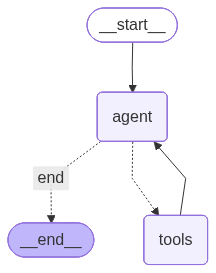

In [19]:
from IPython.display  import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
from langchain_core.messages import HumanMessage

query = '15억짜리 집 1개있을때 종합부동산세를 계산해주세요'

# stream() -> astream() 으로 변경하고 앞에 await를 붙입니다.
async for chunk in graph.astream({"messages": [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

15억짜리 집 1개있을때 종합부동산세를 계산해주세요
================================== Ai Message ==================================
Tool Calls:
  retrieve_context (call_kNp1Y9AUySqRnjSQD9PPRe1Y)
 Call ID: call_kNp1Y9AUySqRnjSQD9PPRe1Y
  Args:
    query: 15억 주택 종합부동산세 계산 2023
================================= Tool Message =================================
Name: retrieve_context

Source: {'source': 'output_real_estate_tax.txt'}
Content: 납세의무자가 3주택 이상을 소유한 경우

| 과세표준            | 세율                                                                 |
| ------------------- | -------------------------------------------------------------------- |
| 3억원 이하           | 1천분의 5                                                            |
| 3억원 초과 6억원 이하 | 150만원+(3억 원을 초과하는 금액의 1천분의 7)                            |
| 6억원 초과 12억원 이하 | 360만원+(6억원을 초과하는 금액의 1천분의 10)                           |
| 12억원 초과 25억원 이하 | 960만원+(12억원을 초과하는 금액의 20)      